<h2 style="text-align: center;"> EXAMEN PRÁCTICO - TERCER PARCIAL </h2>

<img src="img/ITQ.jpg" width="700">

**Nombre:** *Sebastian Sampedro* <br>
**Fecha:** *12/6/2026* <br>
**Link Github:** "https://github.com/sdsampedro-byte/Python2026ML"

#### 0) Cargar una de las imágenes histológicas

In [ ]:
# Utilizar la librería skimage.io para leer la imagen 'histo_x.jpg' en formato RGB.
# Normalizar la imagen para que los píxeles se encuentren en el rango [0, 1]
# Visualizar la imagen

In [1]:
# Importación de librerías necesarias
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops # Para descriptores de textura
from skimage.measure import regionprops, label # Para descriptores de forma
from skimage import io

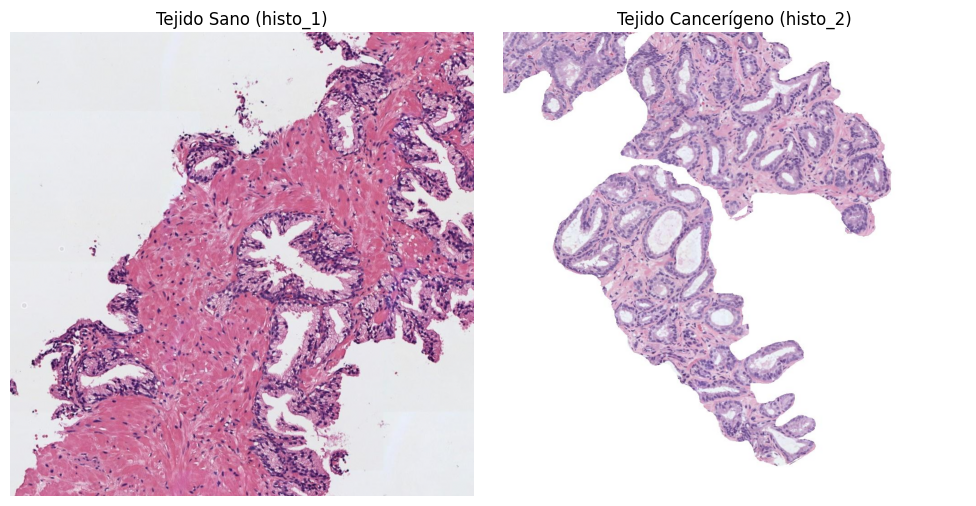

In [2]:
# 1. Utilizar la librería skimage.io para leer las imágenes en formato RGB
img_sana = io.imread('histo_1.jpg')
img_cancer = io.imread('histo_2.jpg')

# 2. Normalizar las imágenes para que los píxeles se encuentren en el rango [0, 1]
# Las imágenes digitales tienen valores de 0 a 255, así que dividimos para normalizar
img_sana_norm = img_sana / 255.0
img_cancer_norm = img_cancer / 255.0

# 3. Visualizar las imágenes
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(img_sana_norm)
ax[0].set_title('Tejido Sano (histo_1)')
ax[0].axis('off')

ax[1].imshow(img_cancer_norm)
ax[1].set_title('Tejido Cancerígeno (histo_2)')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 1) Realizar una transformación de color para convertir la imagen al espacio de color CMYK

In [3]:
# Extraer la componente magenta de la imagen (que corresponde a la región tisular)
# Visualizar la imagen del canal magenta

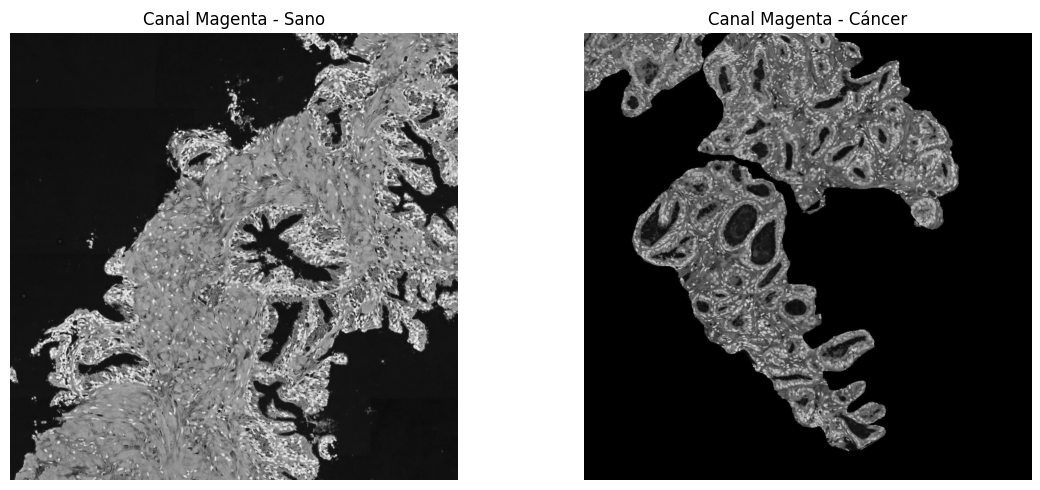

In [4]:
# 1. Extraer la componente magenta (M = 1 - G)
# El canal Verde corresponde al índice 1 en la matriz RGB (0:R, 1:G, 2:B)
magenta_sana = 1.0 - img_sana_norm[:, :, 1]
magenta_cancer = 1.0 - img_cancer_norm[:, :, 1]

# 2. Visualizar la imagen del canal magenta
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Se utiliza cmap='gray' para visualizar la intensidad del canal
ax[0].imshow(magenta_sana, cmap='gray')
ax[0].set_title('Canal Magenta - Sano')
ax[0].axis('off')

ax[1].imshow(magenta_cancer, cmap='gray')
ax[1].set_title('Canal Magenta - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 2) Umbralizar la imagen para separar los píxeles del fondo de la región tisular

In [5]:
# Aplicar un filtro gaussiano de tamaño 5x5 y después utilizar el método de Otsu de manera que
# los píxeles correspondientes al lumen y al background de la imagen sean 1s y el resto de los píxeles tengan un valor de 0.
# Nota: Recordar que el método de Otsu requiere como input una imagen en el rango [0-255] en formato "uint8".
# Visualizar la máscara resultante

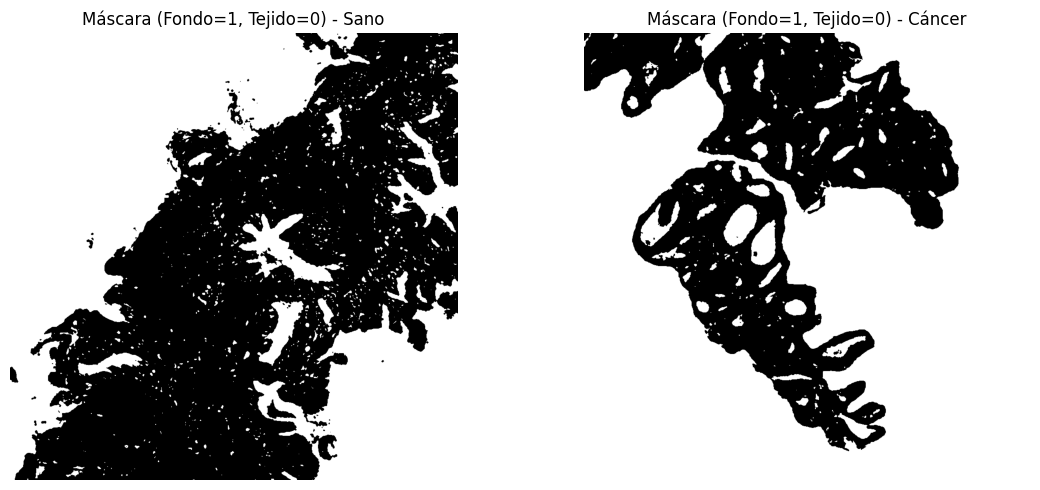

In [6]:
# 1. Convertir las imágenes del canal magenta al rango [0-255] en formato uint8
magenta_sana_uint8 = (magenta_sana * 255).astype(np.uint8)
magenta_cancer_uint8 = (magenta_cancer * 255).astype(np.uint8)

# 2. Aplicar un filtro gaussiano de tamaño 5x5
# El 0 al final indica que OpenCV calcule automáticamente la desviación estándar (sigma)
blur_sana = cv2.GaussianBlur(magenta_sana_uint8, (5, 5), 0)
blur_cancer = cv2.GaussianBlur(magenta_cancer_uint8, (5, 5), 0)

# 3. Aplicar el método de Otsu
# Usamos THRESH_BINARY_INV para que el fondo (oscuro) pase a ser 1 y el tejido (claro) pase a ser 0
# El valor '1' es el valor máximo que tomarán los píxeles umbralizados
_, mask_sana = cv2.threshold(blur_sana, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
_, mask_cancer = cv2.threshold(blur_cancer, 0, 1, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# 4. Visualizar la máscara resultante
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Usamos vmax=1 para que matplotlib entienda que el blanco absoluto es 1 y el negro es 0
ax[0].imshow(mask_sana, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Máscara (Fondo=1, Tejido=0) - Sano')
ax[0].axis('off')

ax[1].imshow(mask_cancer, cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Máscara (Fondo=1, Tejido=0) - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 3) Limpiar la imagen eliminando los artefactos de lumen (objetos blancos pequeños que no son lúmenes)

In [7]:
# Utilizar la librería skimage.morphology.remove_small_objects para eliminar aquellos objetos cuya área sea menor a 300 píxeles
# Más información en https://scikit-image.org/docs/dev/api/skimage.morphology.html#skimage.morphology.remove_small_objects
# Visualizar la máscara resultante

C:\Users\Sebas\AppData\Local\Temp\ipykernel_1664\1336998617.py:8: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_sana_clean = remove_small_objects(mask_sana_bool, min_size=300)
C:\Users\Sebas\AppData\Local\Temp\ipykernel_1664\1336998617.py:9: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask_cancer_clean = r

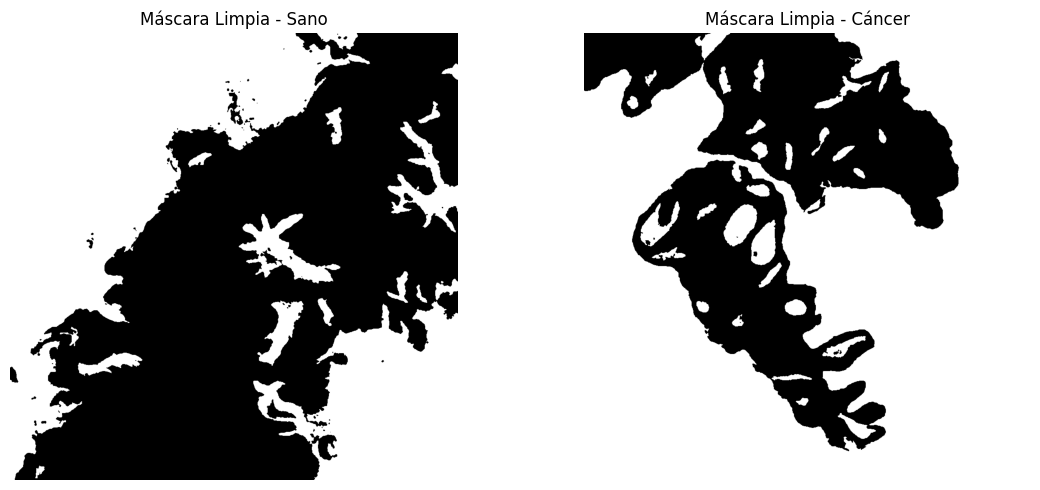

In [8]:
from skimage.morphology import remove_small_objects

# 1. Convertir las máscaras a tipo booleano (requerido por la función)
mask_sana_bool = mask_sana.astype(bool)
mask_cancer_bool = mask_cancer.astype(bool)

# 2. Eliminar objetos pequeños (área menor a 300 píxeles)
mask_sana_clean = remove_small_objects(mask_sana_bool, min_size=300)
mask_cancer_clean = remove_small_objects(mask_cancer_bool, min_size=300)

# 3. Convertir de nuevo a enteros (0 y 1) para visualización y futuros cálculos
mask_sana_clean = mask_sana_clean.astype(np.uint8)
mask_cancer_clean = mask_cancer_clean.astype(np.uint8)

# 4. Visualizar la máscara resultante
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(mask_sana_clean, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Máscara Limpia - Sano')
ax[0].axis('off')

ax[1].imshow(mask_cancer_clean, cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Máscara Limpia - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 4) Rellenar con 0s el fondo de la imagen para quedarnos únicamente con los lúmenes

In [9]:
# Aplicar el algoritmo de expansión a partir de semillas (region growing) de manera que únicamente los lúmenes sean blancos y el resto de la imagen negra. 
# Pista: utilizar dos semillas. Nota: Se pueden fijar las semillas de manera manual, pero se valorará positivamente a aquell@s que desarrollen una función para encontrarlas automáticamente.
# Visualizar la máscara resultante. 

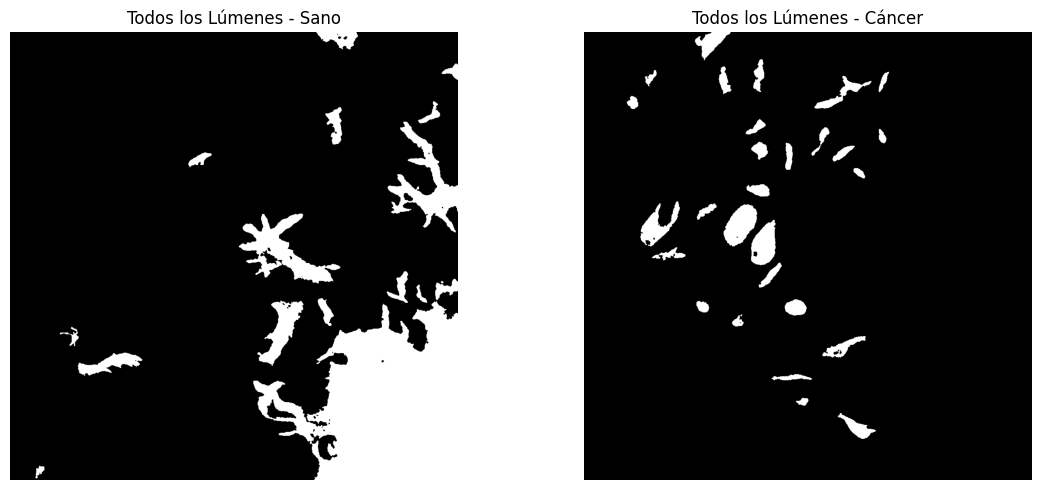

In [10]:
# Función infalible para encontrar semillas
def encontrar_todas_semillas_lumen_corregido(mascara):
    etiquetas = label(mascara)
    propiedades = regionprops(etiquetas)
    
    regiones_ordenadas = sorted(propiedades, key=lambda x: x.area, reverse=True)
    
    semillas = []
    # Omitimos el fondo (índice 0)
    for reg in regiones_ordenadas[1:]:
        # Tomamos la coordenada exacta del primer píxel de la región (y, x)
        y, x = reg.coords[0]
        semillas.append((int(x), int(y)))
        
    return semillas

# 1. Obtener TODAS las semillas exactas
semillas_sana = encontrar_todas_semillas_lumen_corregido(mask_sana_clean)
semillas_cancer = encontrar_todas_semillas_lumen_corregido(mask_cancer_clean)

# 2. Inicializar lienzos completamente negros (0s)
lumen_sano = np.zeros_like(mask_sana_clean)
lumen_cancer = np.zeros_like(mask_cancer_clean)

# Copias de trabajo
mask_sana_flood = mask_sana_clean.copy()
mask_cancer_flood = mask_cancer_clean.copy()

# 3. Aplicar floodFill para el tejido sano
for seed in semillas_sana:
    cv2.floodFill(mask_sana_flood, None, seed, 255)
    lumen_sano[mask_sana_flood == 255] = 1
    mask_sana_flood[mask_sana_flood == 255] = 0

# 4. Aplicar floodFill para el tejido con cáncer
for seed in semillas_cancer:
    cv2.floodFill(mask_cancer_flood, None, seed, 255)
    lumen_cancer[mask_cancer_flood == 255] = 1
    mask_cancer_flood[mask_cancer_flood == 255] = 0

# 5. Visualizar el resultado final
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(lumen_sano, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Todos los Lúmenes - Sano')
ax[0].axis('off')

ax[1].imshow(lumen_cancer, cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Todos los Lúmenes - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 5) Rellenar los objetos de los lúmenes

In [11]:
# Rellenar los lúmenes con la función binary_fill_holes de la librería scipy.ndimage.morphology
# Visualizar la máscara resultante

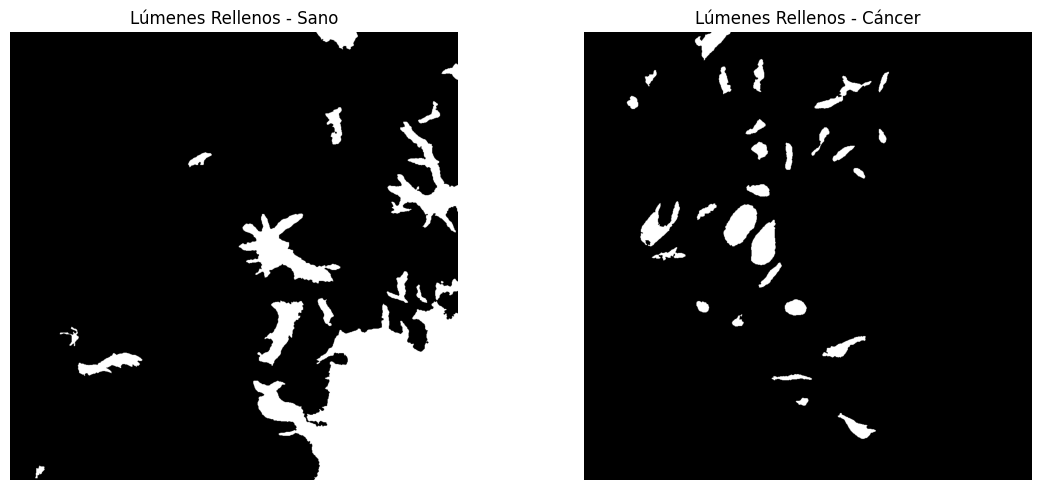

In [12]:
from scipy.ndimage import binary_fill_holes

# 1. Aplicar binary_fill_holes a nuestras máscaras
# La función devuelve una matriz booleana (True/False), así que la pasamos a uint8 (1/0)
lumen_sano_filled = binary_fill_holes(lumen_sano).astype(np.uint8)
lumen_cancer_filled = binary_fill_holes(lumen_cancer).astype(np.uint8)

# 2. Visualizar la máscara resultante
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(lumen_sano_filled, cmap='gray', vmin=0, vmax=1)
ax[0].set_title('Lúmenes Rellenos - Sano')
ax[0].axis('off')

ax[1].imshow(lumen_cancer_filled, cmap='gray', vmin=0, vmax=1)
ax[1].set_title('Lúmenes Rellenos - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 6) Detectar y dibujar los contornos de los lúmenes sobre la imagen original

In [13]:
# Dibujar los contornos de los lúmenes en color verde sobre la imagen original RGB. Nota: Utilizar los flags necesarios
# para que los contornos en verde sean perfectamente visibles. 
# Visualizar la imagen superpuesta

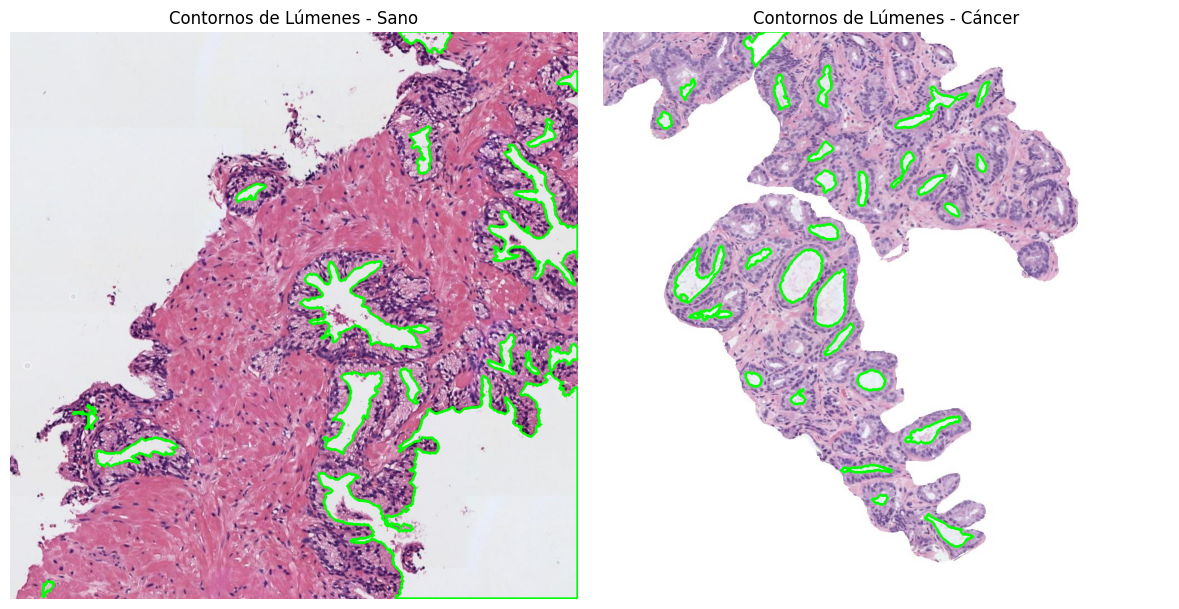

In [14]:
# 1. Encontrar los contornos usando OpenCV
# cv2.RETR_EXTERNAL: Solo recupera los contornos externos (ideal porque ya rellenamos los huecos)
# cv2.CHAIN_APPROX_SIMPLE: Optimiza la memoria guardando solo los puntos clave del contorno
contornos_sano, _ = cv2.findContours(lumen_sano_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contornos_cancer, _ = cv2.findContours(lumen_cancer_filled, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 2. Hacer una copia de las imágenes ORIGINALES (antes de la normalización) para no dañar los datos originales
# Como usamos skimage.io en el Paso 1, img_sana e img_cancer ya están en formato RGB [0-255]
img_sana_contornos = img_sana.copy()
img_cancer_contornos = img_cancer.copy()

# 3. Dibujar los contornos
# El flag -1 indica que dibuje TODOS los contornos de la lista. 
# (0, 255, 0) es el color Verde en RGB. thickness=3 lo hace perfectamente visible.
cv2.drawContours(img_sana_contornos, contornos_sano, -1, (0, 255, 0), thickness=3)
cv2.drawContours(img_cancer_contornos, contornos_cancer, -1, (0, 255, 0), thickness=3)

# 4. Visualizar los resultados
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(img_sana_contornos)
ax[0].set_title('Contornos de Lúmenes - Sano')
ax[0].axis('off')

ax[1].imshow(img_cancer_contornos)
ax[1].set_title('Contornos de Lúmenes - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 7) Identificar y cropear el lumen más grande

In [15]:
# Determinar cuál es el lumen de mayor área y hacer un crop del mismo sobre la imagen original RGB.
# Visualizar el lumen cropeado.

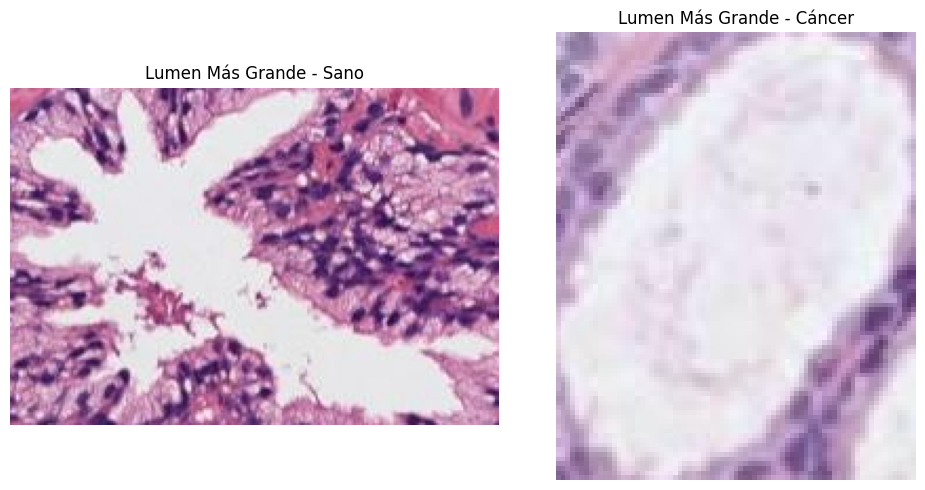

In [19]:
# Función ajustada para elegir qué número de lumen queremos (1º, 2º, 3º más grande...)
def cropear_lumen_n(imagen_rgb, mascara_rellena, n_lumen=1):
    etiquetas = label(mascara_rellena)
    propiedades = regionprops(etiquetas)
    
    # Ordenamos las regiones por área de MAYOR a MENOR
    regiones_ordenadas = sorted(propiedades, key=lambda r: r.area, reverse=True)
    
    # Seleccionamos el lumen deseado (restando 1 porque los índices en Python empiezan en 0)
    region_objetivo = regiones_ordenadas[n_lumen - 1]
    
    # Extraemos las coordenadas de la caja delimitadora
    min_row, min_col, max_row, max_col = region_objetivo.bbox
    
    # Recortamos la imagen
    imagen_recortada = imagen_rgb[min_row:max_row, min_col:max_col]
    
    return imagen_recortada

# 1. Para el Sano pedimos el 2do más grande (n_lumen=2). Para el Cáncer pedimos el 1ro (n_lumen=1).
lumen_sano_crop = cropear_lumen_n(img_sana, lumen_sano_filled, n_lumen=2)
lumen_cancer_crop = cropear_lumen_n(img_cancer, lumen_cancer_filled, n_lumen=1)

# 2. Visualizar los recortes resultantes
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].imshow(lumen_sano_crop)
ax[0].set_title('Lumen Más Grande - Sano')
ax[0].axis('off')

ax[1].imshow(lumen_cancer_crop)
ax[1].set_title('Lumen Más Grande - Cáncer')
ax[1].axis('off')

plt.tight_layout()
plt.show()

#### 8) Extraer 13 características geométricas que permitan caracterizar el lumen recortado 

In [17]:
# Calcular las siguientes características del crop del lumen de mayor área, redondeando su valor hasta el cuarto decimal.
# 1) Área
# 2) Área de la bounding box
# 3) Área convexa
# 4) Exentricidad
# 5) Diámetro equivalente
# 6) Extensión
# 7) Diámetro Feret
# 8) Longitud del eje mayor
# 9) Longitud del eje menor
# 10) Orientación
# 11) Perímetro
# 12) Solidez
# 13) Compacidad

In [18]:
# Función para extraer las 13 características solicitadas
def extraer_13_caracteristicas(mascara_rellena, n_lumen=1):
    etiquetas = label(mascara_rellena)
    propiedades = regionprops(etiquetas)
    
    # Ordenamos de mayor a menor área para seleccionar el lumen correcto
    regiones_ordenadas = sorted(propiedades, key=lambda r: r.area, reverse=True)
    region = regiones_ordenadas[n_lumen - 1]
    
    # Extraemos características de regionprops de forma segura para compatibilidad de versiones
    area = region.area
    bbox_area = region.bbox_area
    convex_area = region.convex_area
    eccentricity = region.eccentricity
    eq_diameter = getattr(region, 'equivalent_diameter_area', getattr(region, 'equivalent_diameter', 0))
    extent = region.extent
    feret = getattr(region, 'feret_diameter_max', 0)
    major_axis = getattr(region, 'axis_major_length', getattr(region, 'major_axis_length', 0))
    minor_axis = getattr(region, 'axis_minor_length', getattr(region, 'minor_axis_length', 0))
    orientation = region.orientation
    perimeter = region.perimeter
    solidity = region.solidity
    
    # Calculamos la Compacidad manualmente
    compacidad = (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0
    
    # Armamos un diccionario con el redondeo exacto a 4 decimales
    caracteristicas = {
        "1) Área": round(area, 4),
        "2) Área de la bounding box": round(bbox_area, 4),
        "3) Área convexa": round(convex_area, 4),
        "4) Excentricidad": round(eccentricity, 4),
        "5) Diámetro equivalente": round(eq_diameter, 4),
        "6) Extensión": round(extent, 4),
        "7) Diámetro Feret": round(feret, 4),
        "8) Longitud del eje mayor": round(major_axis, 4),
        "9) Longitud del eje menor": round(minor_axis, 4),
        "10) Orientación": round(orientation, 4),
        "11) Perímetro": round(perimeter, 4),
        "12) Solidez": round(solidity, 4),
        "13) Compacidad": round(compacidad, 4)
    }
    
    return caracteristicas

# 1. Aplicamos la función usando el índice correcto (2do lumen sano, 1er lumen cáncer)
feats_sano = extraer_13_caracteristicas(lumen_sano_filled, n_lumen=2)
feats_cancer = extraer_13_caracteristicas(lumen_cancer_filled, n_lumen=1)

# 2. Mostramos los datos en una tabla comparativa con Pandas
df_caracteristicas = pd.DataFrame({
    'Tejido Sano (Lumen Objetivo)': feats_sano,
    'Tejido Cáncer (Lumen Objetivo)': feats_cancer
})

print("--- 13 Características Geométricas Extraídas ---")
display(df_caracteristicas) # display() formatea la tabla visualmente en Jupyter

--- 13 Características Geométricas Extraídas ---


C:\Users\Sebas\AppData\Local\Temp\ipykernel_1664\3025897096.py:12: FutureWarning: `RegionProperties.bbox_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_bbox` instead. 
  bbox_area = region.bbox_area
C:\Users\Sebas\AppData\Local\Temp\ipykernel_1664\3025897096.py:13: FutureWarning: `RegionProperties.convex_area` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.area_convex` instead. 
  convex_area = region.convex_area
C:\Users\Sebas\AppData\Local\Temp\ipykernel_1664\3025897096.py:15: FutureWarning: `RegionProperties.equivalent_diameter` is deprecated starting in version 0.26 and will be removed in version 2.0. Use `RegionProperties.equivalent_diameter_area` instead. 
  eq_diameter = getattr(region, 'equivalent_diameter_area', getattr(region, 'equivalent_diameter', 0))
C:\Users\Sebas\AppData\Local\Temp\ipykernel_1664\3025897096.py:18: FutureWarning: `RegionProperties.major_axis_leng

,Tejido Sano (Lumen Objetivo),Tejido Cáncer (Lumen Objetivo)
1) Área,13317.0000,4698.0000
2) Área de la bounding box,37120.0000,7392.0000
3) Área convexa,27221.0000,4884.0000
4) Excentricidad,0.8450,0.8377
5) Diámetro equivalente,130.2142,77.3413
6) Extensión,0.3588,0.6356
7) Diámetro Feret,242.5387,104.3168
8) Longitud del eje mayor,231.2462,104.9191
9) Longitud del eje menor,123.6802,57.3033
10) Orientación,0.9957,-0.5621
